# Artificial Neural Networks on Tabular Data

In [2]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)
np.random.seed(42)

In [3]:
X_train = joblib.load("X_train.pkl").values.astype(np.float32)
X_test  = joblib.load("X_test.pkl").values.astype(np.float32)
y_train = joblib.load("y_train.pkl").values.astype(np.float32)
y_test  = joblib.load("y_test.pkl").values.astype(np.float32)
cw      = joblib.load("class_weights.pkl")

input_dim = X_train.shape[1]

**SLP**

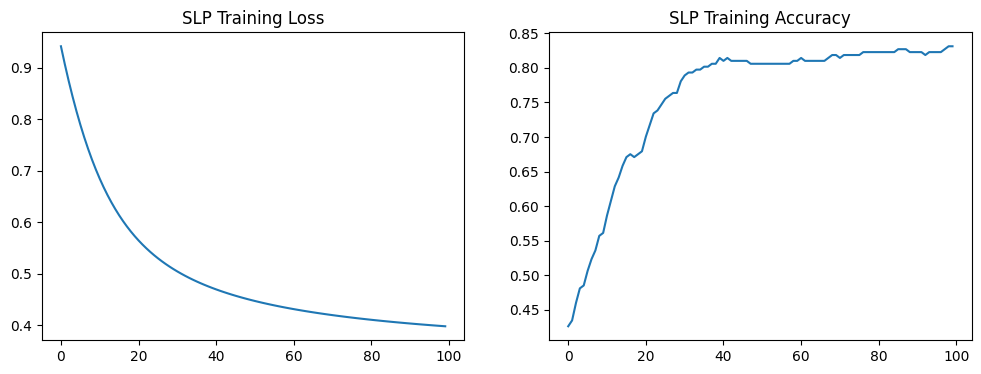

In [4]:
slp = Sequential([
    Dense(1, input_dim=input_dim, activation='sigmoid')
])

slp.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
            loss='binary_crossentropy',
            metrics=['accuracy'])

hist_slp = slp.fit(X_train, y_train, epochs=100,
                   class_weight=cw, verbose=0)

plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(hist_slp.history['loss'])
plt.title("SLP Training Loss")

plt.subplot(1,2,2)
plt.plot(hist_slp.history['accuracy'])
plt.title("SLP Training Accuracy")
plt.show()

In [5]:
feature_names = joblib.load("X_train.pkl").columns.tolist()
weights = slp.layers[0].get_weights()[0].flatten()
top3_idx = np.argsort(np.abs(weights))[::-1][:3]

print("Top 3 features by SLP weight:")
for i in top3_idx:
    print(f"  {feature_names[i]}: {weights[i]:.4f}")

Top 3 features by SLP weight:
  cp_4.0: 0.6904
  thal_7.0: 0.6702
  thal_3.0: -0.6483


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
              precision    recall  f1-score   support

         0.0       0.88      0.91      0.89        32
         1.0       0.89      0.86      0.87        28

    accuracy                           0.88        60
   macro avg       0.88      0.88      0.88        60
weighted avg       0.88      0.88      0.88        60

AUC: 0.9241


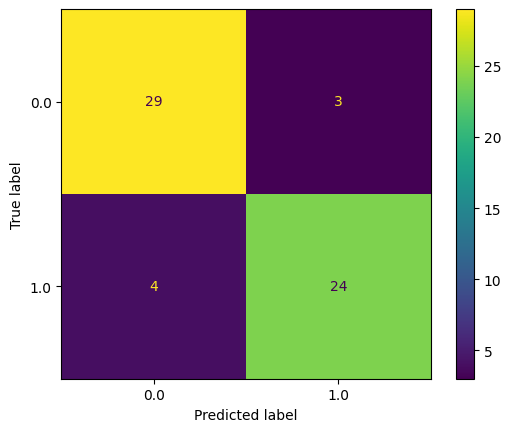

In [6]:
y_prob_slp = slp.predict(X_test).flatten()
y_pred_slp = (y_prob_slp >= 0.5).astype(int)

print(classification_report(y_test, y_pred_slp))
print("AUC:", round(roc_auc_score(y_test, y_prob_slp), 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_slp)
plt.show()

##MLP

In [7]:
def build_mlp(layers):
    model = Sequential()
    model.add(Dense(layers[0], input_dim=input_dim, activation='relu'))
    for units in layers[1:]:
        model.add(Dense(units, activation='relu'))
        model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

architectures = {
    "Small":  [32],
    "Medium": [64, 32],
    "Large":  [128, 64, 32]
}

es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
results_mlp = {}

for name, layers in architectures.items():
    model = build_mlp(layers)
    hist  = model.fit(X_train, y_train, epochs=150, batch_size=32,
                      validation_split=0.2, callbacks=[es],
                      class_weight=cw, verbose=0)
    y_prob = model.predict(X_test).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    from sklearn.metrics import f1_score
    f1 = round(f1_score(y_test, y_pred), 4)
    results_mlp[name] = f1
    print(f"{name}: Val F1 = {f1}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Small: Val F1 = 0.8302


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
Medium: Val F1 = 0.7879
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Large: Val F1 = 0.8519


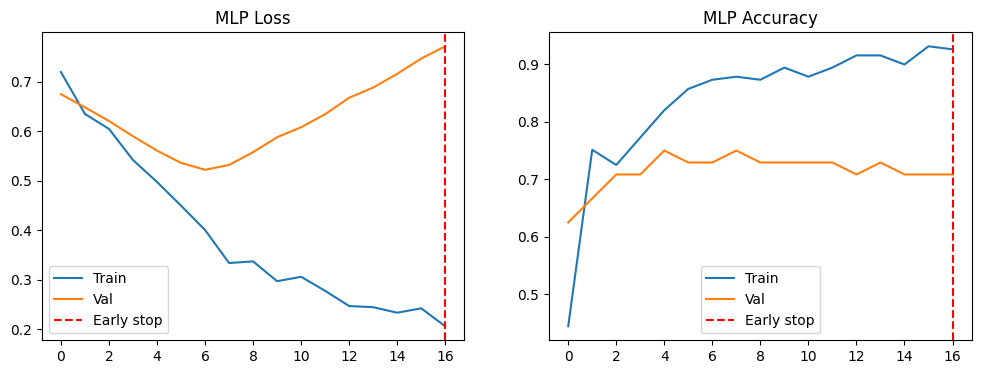

In [8]:
best_mlp = build_mlp([128, 64, 32])
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

hist_mlp = best_mlp.fit(X_train, y_train, epochs=150, batch_size=32,
                        validation_split=0.2, callbacks=[es],
                        class_weight=cw, verbose=0)

stop_epoch = len(hist_mlp.history['loss'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(hist_mlp.history['loss'],     label='Train')
ax1.plot(hist_mlp.history['val_loss'], label='Val')
ax1.axvline(x=stop_epoch-1, color='red', linestyle='--', label='Early stop')
ax1.set_title("MLP Loss")
ax1.legend()

ax2.plot(hist_mlp.history['accuracy'],     label='Train')
ax2.plot(hist_mlp.history['val_accuracy'], label='Val')
ax2.axvline(x=stop_epoch-1, color='red', linestyle='--', label='Early stop')
ax2.set_title("MLP Accuracy")
ax2.legend()
plt.show()

In [9]:
from sklearn.metrics import f1_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_acc, cv_f1 = [], []

for train_idx, val_idx in skf.split(X_train, y_train):
    Xtr, Xv = X_train[train_idx], X_train[val_idx]
    ytr, yv = y_train[train_idx], y_train[val_idx]

    m = build_mlp([128, 64, 32])
    m.fit(Xtr, ytr, epochs=100, batch_size=32, verbose=0,
          class_weight=cw)
    yp = (m.predict(Xv).flatten() >= 0.5).astype(int)
    cv_acc.append(np.mean(yp == yv))
    cv_f1.append(f1_score(yv, yp))

print(f"CV Accuracy: {np.mean(cv_acc):.4f} ± {np.std(cv_acc):.4f}")
print(f"CV F1:       {np.mean(cv_f1):.4f} ± {np.std(cv_f1):.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
CV Accuracy: 0.7592 ± 0.0842
CV F1:       0.7401 ± 0.0793


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
              precision    recall  f1-score   support

         0.0       0.82      0.88      0.85        32
         1.0       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60

AUC: 0.9442


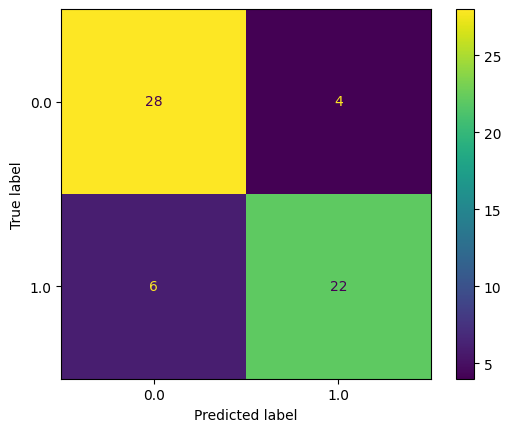

In [10]:
y_prob_mlp = best_mlp.predict(X_test).flatten()
y_pred_mlp = (y_prob_mlp >= 0.5).astype(int)

print(classification_report(y_test, y_pred_mlp))
print("AUC:", round(roc_auc_score(y_test, y_prob_mlp), 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_mlp)
plt.show()

##Ablation Study

In [11]:
def build_no_dropout(layers):
    model = Sequential()
    model.add(Dense(layers[0], input_dim=input_dim, activation='relu'))
    for units in layers[1:]:
        model.add(Dense(units, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_sigmoid(layers):
    model = Sequential()
    model.add(Dense(layers[0], input_dim=input_dim, activation='sigmoid'))
    for units in layers[1:]:
        model.add(Dense(units, activation='sigmoid'))
        model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

variant_a = build_no_dropout([128, 64, 32])
variant_a.fit(X_train, y_train, epochs=150, batch_size=32,
              validation_split=0.2, callbacks=[es],
              class_weight=cw, verbose=0)

variant_b = build_sigmoid([128, 64, 32])
variant_b.fit(X_train, y_train, epochs=150, batch_size=32,
              validation_split=0.2, callbacks=[es],
              class_weight=cw, verbose=0)

variant_c = build_mlp([128, 64, 32])
variant_c.fit(X_train, y_train, epochs=150, batch_size=32,
              validation_split=0.2, class_weight=cw, verbose=0)

In [12]:
ablation_results = {}
for name, model in [("Best MLP", best_mlp), ("A: No Dropout", variant_a),
                    ("B: Sigmoid", variant_b), ("C: No EarlyStopping", variant_c)]:
    yp = (model.predict(X_test).flatten() >= 0.5).astype(int)
    ablation_results[name] = round(f1_score(y_test, yp), 4)

print(pd.DataFrame.from_dict(ablation_results, orient='index', columns=['Test F1']))


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
                     Test F1
Best MLP              0.8148
A: No Dropout         0.8077
B: Sigmoid            0.4516
C: No EarlyStopping   0.8214


In [13]:
best_mlp.save("best_mlp.h5")
print("MLP saved.")

MLP saved.
